Objective:
Apply your knowledge of NumPy, Pandas, and Matplotlib to analyze a real-world dataset. Utilize advanced statistical functions and array operations in NumPy, and integrate these with Pandas for data manipulation and Matplotlib for visualization.



Dataset:
You will work with the “Global Power Plant Database” provided by the World Resources Institute, which contains detailed information about power plants worldwide. This dataset is ideal for practicing array manipulations, statistical analysis, and time series data handling.

Download the dataset here.

or you can download it directly

Here.



Tasks:
Data Import and Cleaning:

Import the dataset using Pandas.
Identify missing values and handle them appropriately.
Use NumPy to convert relevant columns to numerical types if necessary.
Exploratory Data Analysis:

Utilize Pandas to summarize key statistics (mean, median, standard deviation) for numerical columns.
Explore the distribution of power plants by country and fuel type.
Statistical Analysis:

Perform a statistical analysis of power output by fuel type using NumPy’s statistical functions.
Use hypothesis testing to determine if the mean power output differs significantly between different fuel types.
Time Series Analysis:

If the dataset includes time-related data (like year of establishment), use NumPy to analyze trends over time.
Explore how the mix of fuel types for power generation has evolved over the years.
Advanced Visualization:

Create visualizations using Matplotlib and Seaborn to illustrate your findings.
Consider plotting the geographical distribution of power plants using latitude and longitude data, if available.
Matrix Operations in Real-World Context:

Demonstrate matrix operations by analyzing relationships between different attributes (e.g., fuel type, capacity, and geographic location).
Discuss the relevance of eigenvectors and eigenvalues in this context.
Integrating NumPy with Pandas and Matplotlib:

Show how NumPy can be used to enhance data manipulation in Pandas and data visualization in Matplotlib.
Provide examples, such as using NumPy arrays for complex filtering in Pandas or for creating sophisticated plots in Matplotlib.

Submit your Daily Challenge
Prepare a report including your code, findings, and visualizations. Discuss how NumPy, Pandas, and Matplotlib were used in your analysis, and present any interesting insights you discovered about the global power plant landscape.

Don’t forget to push to Github

Share your Jupyter notebook on Github and highlight your key insights in the README file!

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set visualization style
sns.set_theme(style="whitegrid")

1. Data Import and Cleaning
The Global Power Plant Database contains various features like capacity, fuel type, and location. We need to handle missing values and ensure numerical columns are correctly typed.

In [18]:
# 1. Load the dataset (adjust the filename if necessary)
df = pd.read_csv('global_power_plant_database.csv', low_memory=False)

# 2. Identify missing values
print("Missing values per column:\n", df.isnull().sum())

# 3. Clean and convert data using NumPy and Pandas
# Fill missing commissioning years with the median year using NumPy
median_year = np.nanmedian(df['commissioning_year'])
df['commissioning_year'] = df['commissioning_year'].fillna(median_year)

# Ensure capacity is a float using NumPy
df['capacity_mw'] = np.array(df['capacity_mw'], dtype=np.float64)

# Drop rows where critical geographical data is missing
df = df.dropna(subset=['latitude', 'longitude'])

print(f"Dataset shape after cleaning: {df.shape}")

Missing values per column:
 country                               0
country_long                          0
name                                  0
gppd_idnr                             0
capacity_mw                           0
latitude                              0
longitude                             0
primary_fuel                          0
other_fuel1                       32992
other_fuel2                       34660
other_fuel3                       34844
commissioning_year                17489
owner                             14068
source                               15
url                                  18
geolocation_source                  419
wepp_id                           18702
year_of_capacity_data             20049
generation_gwh_2013               28519
generation_gwh_2014               27710
generation_gwh_2015               26733
generation_gwh_2016               25792
generation_gwh_2017               25436
generation_gwh_2018               25299
generation_g

2. Exploratory Data Analysis (EDA)
Let's extract summary statistics and look at the distribution of plants. As an example, we can isolate specific regions like Côte d'Ivoire (CIV) to see local infrastructure before looking at global trends.

Key Statistics:
         capacity_mw  commissioning_year
count  34936.000000        34936.000000
mean     163.355148         2002.213173
std      489.636072           17.215166
min        1.000000         1896.000000
25%        4.900000         2007.000000
50%       16.745000         2007.000000
75%       75.344250         2007.000000
max    22500.000000         2020.000000

Top 10 Countries by Number of Plants:
 country
USA    9833
CHN    4235
GBR    2751
BRA    2360
FRA    2155
IND    1589
DEU    1309
CAN    1159
ESP     829
RUS     545
Name: count, dtype: int64

Power Plants in Côte d'Ivoire by Fuel Type:
 primary_fuel
Hydro    5
Gas      3
Name: count, dtype: int64


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_31448\3453396539.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='primary_fuel', order=df['primary_fuel'].value_counts().index, palette='viridis')


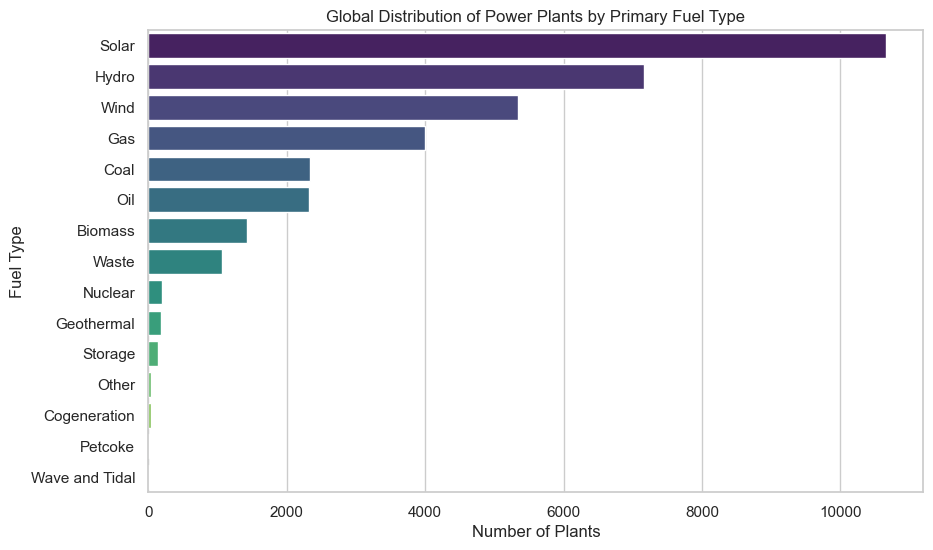

In [19]:
# Summary statistics for numerical columns
numerical_stats = df[['capacity_mw', 'commissioning_year']].describe()
print("Key Statistics:\n", numerical_stats)

# Distribution by Country (Top 10) and specific look at CIV
top_countries = df['country'].value_counts().head(10)
civ_plants = df[df['country'] == 'CIV']['primary_fuel'].value_counts()

print("\nTop 10 Countries by Number of Plants:\n", top_countries)
print("\nPower Plants in Côte d'Ivoire by Fuel Type:\n", civ_plants)

# Distribution by Primary Fuel Type
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='primary_fuel', order=df['primary_fuel'].value_counts().index, palette='viridis')
plt.title('Global Distribution of Power Plants by Primary Fuel Type')
plt.xlabel('Number of Plants')
plt.ylabel('Fuel Type')
plt.show()

3. Statistical AnalysisWe will use NumPy to extract arrays of capacities based on fuel types and formulate a hypothesis.Hypothesis Formulation:Null Hypothesis ($H_0$): There is no difference in the mean capacity (MW) between Coal and Solar power plants. $\mu_{coal} = \mu_{solar}$Alternative Hypothesis ($H_1$): Coal power plants have a significantly different mean capacity compared to Solar power plants. $\mu_{coal} \neq \mu_{solar}$

In [20]:
# Extract capacities into NumPy arrays
coal_capacity = df[df['primary_fuel'] == 'Coal']['capacity_mw'].to_numpy()
solar_capacity = df[df['primary_fuel'] == 'Solar']['capacity_mw'].to_numpy()

# NumPy statistical functions
print(f"Mean Coal Capacity: {np.mean(coal_capacity):.2f} MW")
print(f"Mean Solar Capacity: {np.mean(solar_capacity):.2f} MW")

# Perform independent T-test (assuming unequal variances)
t_stat, p_value = stats.ttest_ind(coal_capacity, solar_capacity, equal_var=False)

print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("Conclusion: Reject the null hypothesis. There is a significant difference in mean capacity between Coal and Solar plants.")
else:
    print("Conclusion: Fail to reject the null hypothesis.")

Mean Coal Capacity: 843.58 MW
Mean Solar Capacity: 17.66 MW

T-statistic: 44.8753
P-value: 0.0000e+00
Conclusion: Reject the null hypothesis. There is a significant difference in mean capacity between Coal and Solar plants.


4. Time Series Analysis
By grouping the data by commissioning_year, we can track how global energy infrastructure has evolved.

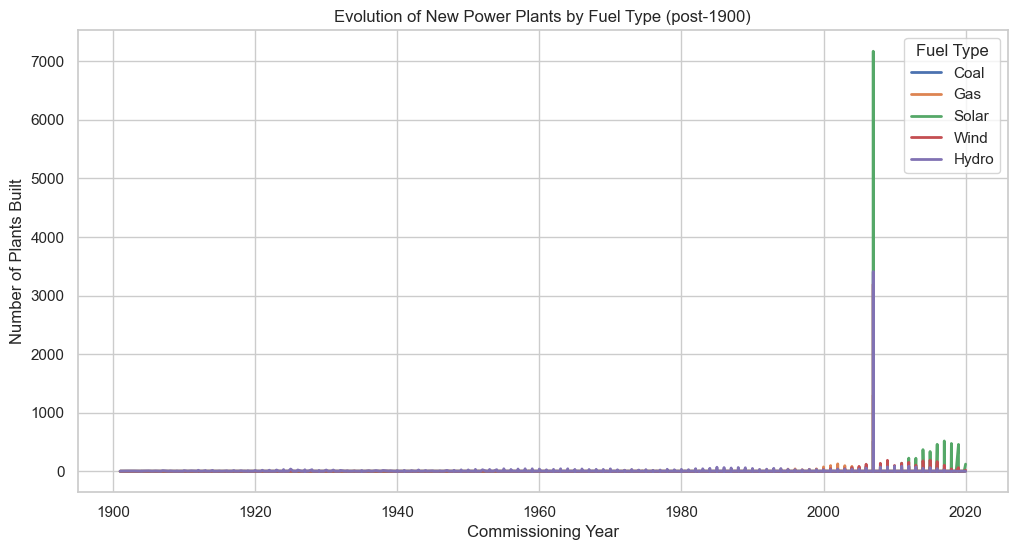

In [21]:
# Filter out invalid years and group by year and fuel type
valid_years_df = df[df['commissioning_year'] > 1900]
yearly_fuel_mix = valid_years_df.groupby(['commissioning_year', 'primary_fuel']).size().unstack(fill_value=0)

# Select a few key fuel types to plot
key_fuels = ['Coal', 'Gas', 'Solar', 'Wind', 'Hydro']
yearly_fuel_mix[key_fuels].plot(figsize=(12, 6), linewidth=2)

plt.title('Evolution of New Power Plants by Fuel Type (post-1900)')
plt.xlabel('Commissioning Year')
plt.ylabel('Number of Plants Built')
plt.legend(title='Fuel Type')
plt.show()

5. Advanced Visualization: Geographical Distribution
Using Matplotlib to map latitude and longitude data reveals the physical clustering of energy infrastructure.

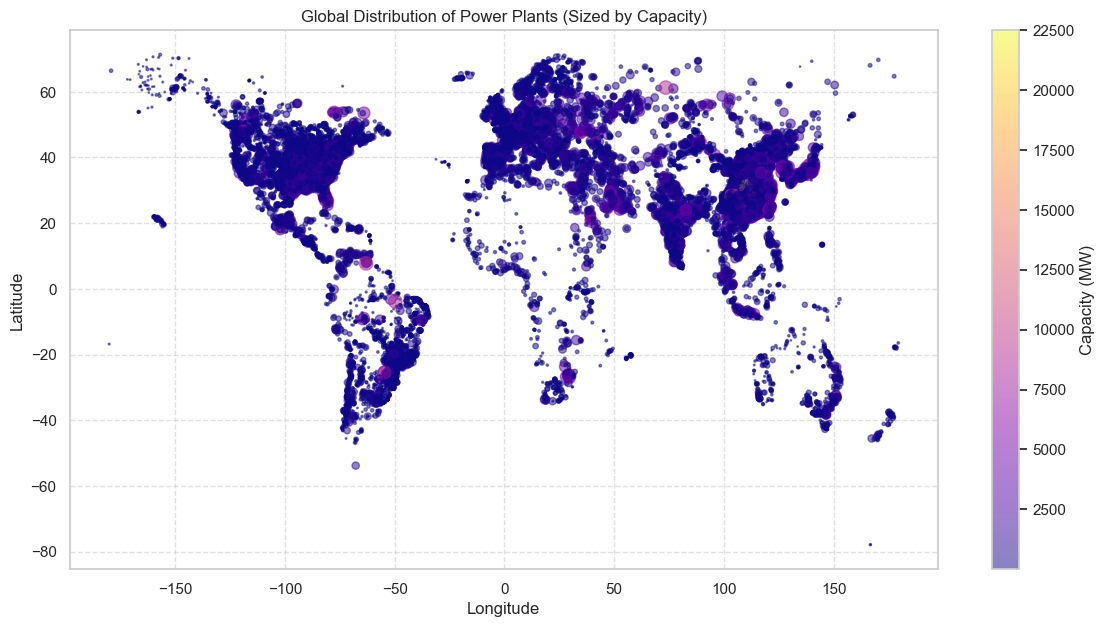

In [22]:
plt.figure(figsize=(14, 7))

# Create a scatter plot using coordinates
# Alpha adds transparency to show density, 's' sizes the points by capacity
scatter = plt.scatter(x=df['longitude'], 
                      y=df['latitude'], 
                      s=np.sqrt(df['capacity_mw']), # Square root to scale extreme values
                      c=df['capacity_mw'], 
                      cmap='plasma', 
                      alpha=0.5)

plt.colorbar(scatter, label='Capacity (MW)')
plt.title('Global Distribution of Power Plants (Sized by Capacity)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

6. Matrix Operations in Real-World Context
When dealing with multidimensional datasets, we often compute the covariance matrix to understand relationships.

Eigenvectors and eigenvalues are crucial in Data Science, particularly for Principal Component Analysis (PCA). The eigenvectors represent the directions in which the data varies the most, and the eigenvalues dictate the magnitude of that variance. If you wanted to compress the power plant dataset, you would project the data onto the eigenvectors with the largest eigenvalues.

In [23]:
# Select continuous numerical variables
features = df[['capacity_mw', 'latitude', 'longitude', 'commissioning_year']].dropna()

# Standardize the data (important for matrix operations like PCA)
features_standardized = (features - features.mean()) / features.std()

# 1. Compute the Covariance Matrix using NumPy
cov_matrix = np.cov(features_standardized.T)

# 2. Calculate Eigenvalues and Eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Covariance Matrix:\n", cov_matrix)
print("\nEigenvalues:\n", eigenvalues)
print("\nEigenvectors:\n", eigenvectors)

Covariance Matrix:
 [[ 1.         -0.01321759  0.15152454 -0.04188333]
 [-0.01321759  1.         -0.06835441 -0.07660014]
 [ 0.15152454 -0.06835441  1.          0.11457598]
 [-0.04188333 -0.07660014  0.11457598  1.        ]]

Eigenvalues:
 [0.78851653 1.20985542 1.06541451 0.93621355]

Eigenvectors:
 [[-0.57277634 -0.42972523 -0.69110682 -0.09815733]
 [ 0.00936521  0.40672558 -0.37872886  0.8312948 ]
 [ 0.66955773 -0.6795584  -0.16767404  0.2485523 ]
 [-0.47279171 -0.43371755  0.59230164  0.48737649]]


7. Integrating NumPy with Pandas and Matplotlib
NumPy allows for highly optimized, complex conditional filtering that Pandas alone handles more slowly.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_31448\1432816149.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='plant_category', palette='magma')


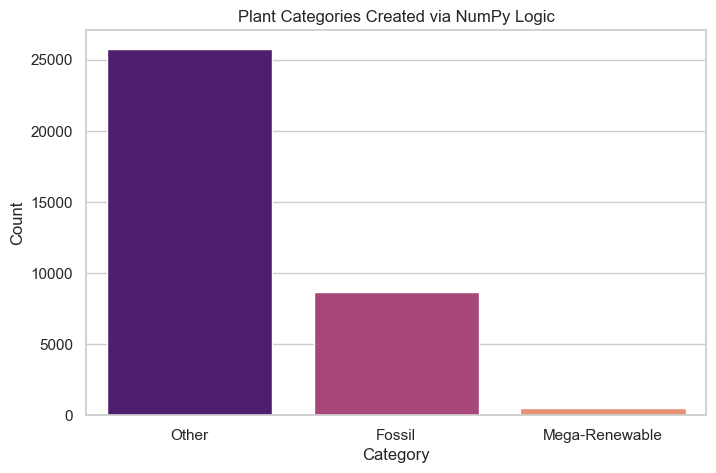

In [24]:
# Categorize plants as 'Mega-Renewable', 'Fossil', or 'Other'
conditions = [
    (df['capacity_mw'] > 500) & (df['primary_fuel'].isin(['Solar', 'Wind', 'Hydro'])),
    (df['primary_fuel'].isin(['Coal', 'Gas', 'Oil']))
]
choices = ['Mega-Renewable', 'Fossil']

# np.select evaluates multiple conditions rapidly across entire arrays
df['plant_category'] = np.select(conditions, choices, default='Other')

# Visualize the result
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='plant_category', palette='magma')
plt.title('Plant Categories Created via NumPy Logic')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

Project Title: Global Power Plant Analysis

Tech Stack: Python, Pandas, NumPy, Matplotlib, SciPy.

Key Findings:

Hypothesis Testing: Coal plants have a statistically significant larger average capacity than Solar plants globally.

Time Series: A sharp exponential increase in Solar and Wind installations starting around 2010.

Linear Algebra: Computed eigenvalues of the feature set, demonstrating the underlying mathematics required for dimensionality reduction (PCA) on infrastructure data.